**Sobre o Conjunto de Dados**: `Fashion MNIST` É um conjunto de imagens de roupas em escala de cinza, onde cada registro representa uma imagem com rótulo e pixels. O objetivo é classificar cada imagem em uma entre 10 categorias.


---




*   Total: 70.000 imagens
*   Dimensão: 28x28 Pixels
*   1 Canal de Cor (Grayscale)
*   10 Classes / Rótulos




---



**Créditos e Mais informações**:

* [TensorFlow](https://www.tensorflow.org/datasets/catalog/fashion_mnist?hl=pt-br)

# Importando o conjunto de dados e bibliotecas 🎲

In [ ]:
import tensorflow as tf
print(tf.__version__)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

2.19.0


In [ ]:
fashion_train_df = pd.read_csv('fashion-mnist-train.csv', sep=',') # Treino
fashion_test_df = pd.read_csv('fashion-mnist-test.csv', sep=',') # Teste

In [ ]:
fashion_train_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
fashion_test_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Rótulos / Classes - Cada número representa um acessório diferente
* 0 = T-shirt/top
* 1 = Trouser
* 2 = Pullover
* 3 = Dress
* 4 = Coat
* 5 = Sandal
* 6 = Shirt
* 7 = Sneaker
* 8 = Bag
* 9 = Ankle boot



---



In [ ]:
fashion_train_df.shape # 60mil registros para treino

(60000, 785)

In [ ]:
fashion_test_df.shape # 10mil registros para teste

(10000, 785)

In [ ]:
train = np.array(fashion_train_df, dtype='float32') # Conversão necessária (TensorFlow)
test = np.array(fashion_test_df, dtype='float32')



---



# Tratamento dos Dados 🧹

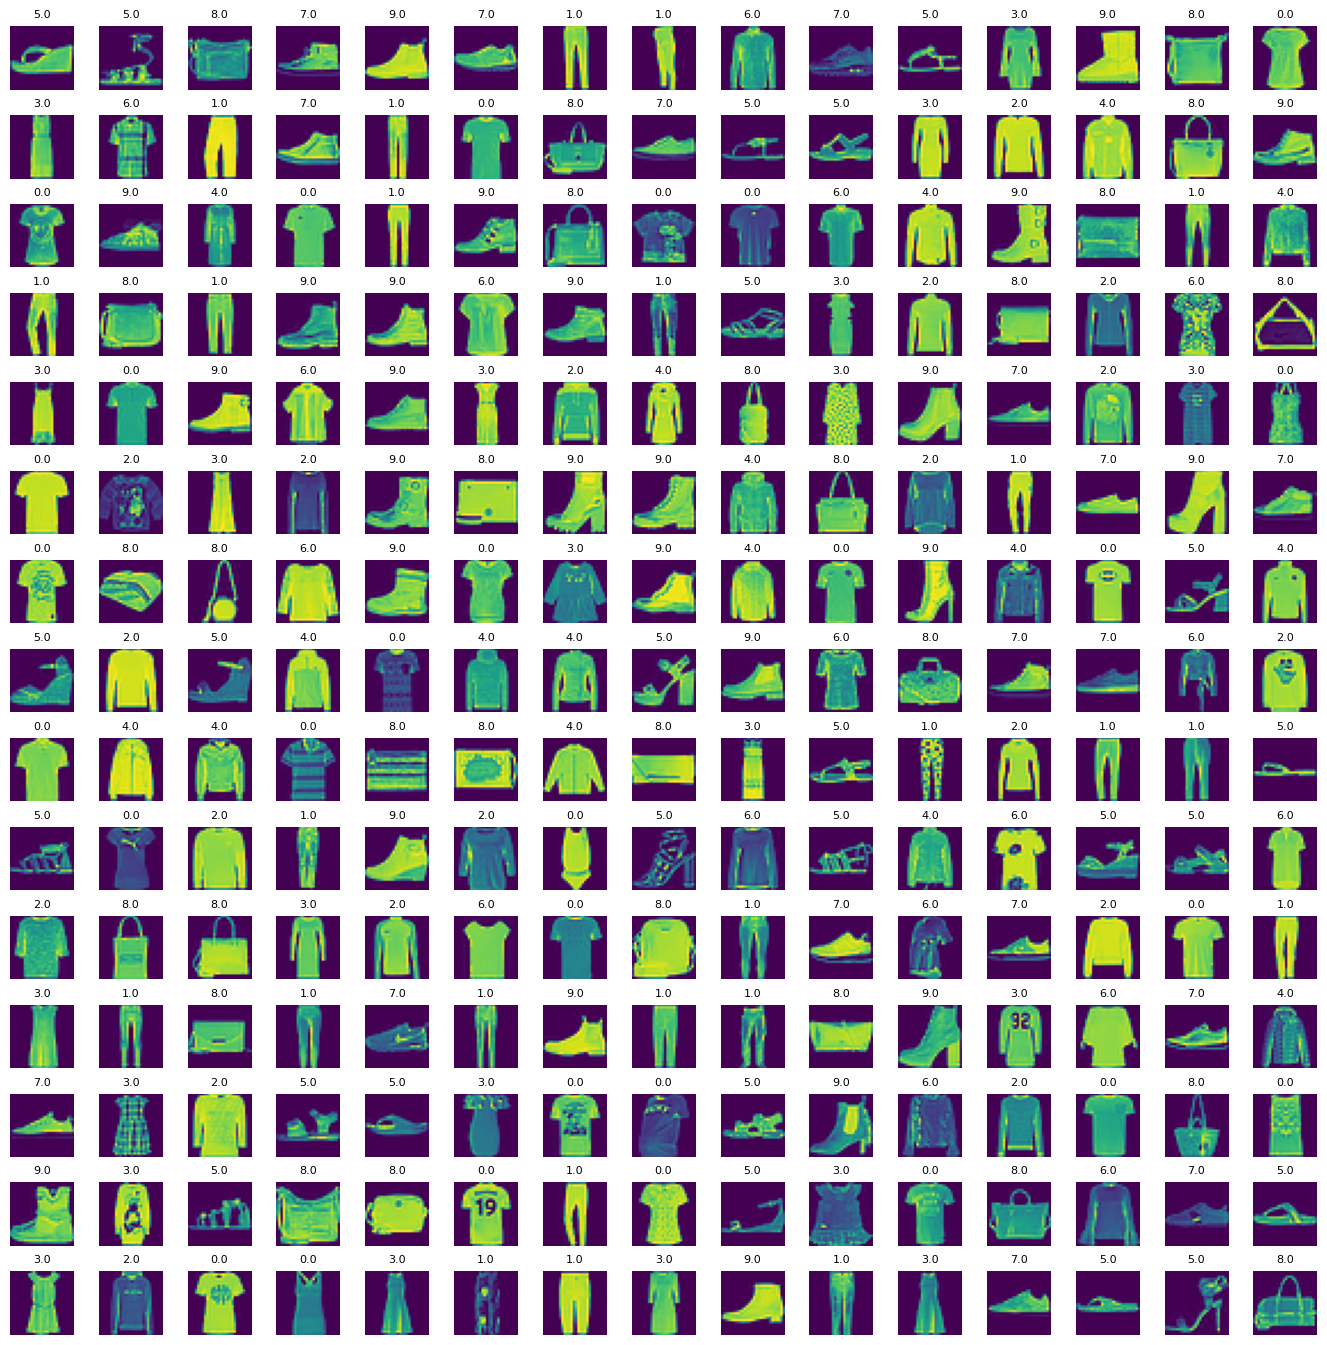

In [ ]:
# Visualização das imagens do dataset e rótulos. Os registros são selecionados de forma aleatória e as imagens são construídas com base em dados, pixels

W_grid = 15
L_grid = 15
fig, axes = plt.subplots(L_grid, W_grid, figsize = (17,17))
axes = axes.ravel()
n_training = len(train)

for i in np.arange(0, W_grid * L_grid):
  index = np.random.randint(0, n_training)
  axes[i].imshow(train[index,1:].reshape((28,28)))
  axes[i].set_title(train[index,0], fontsize = 8)
  axes[i].axis('off')
plt.subplots_adjust(hspace=0.4)

In [ ]:
x_train = train[:, 1:]/255 # Normalização dos atributos previsores, somente os pixels
y_train = train[:, 0] # Classes são armazenadas em y_train (separação entre x e y)

In [ ]:
x_test = test[:, 1:]/255 # Normalização para os dados de teste
y_test = test[:, 0] # Classes são armazenadas em y_test (separação entre x e y)

In [ ]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape # Dimensões finais da separação entre treino e teste

((60000, 784), (60000,), (10000, 784), (10000,))

Após a normalização, os valores dos pixels passam a ser números entre 0 e 1.
A próxima modificação é o Reshape: formato exigido pelo TensorFlow para CNN `(registos, altura, largura, canal)`


In [ ]:
x_train = x_train.reshape(x_train.shape[0], *(28, 28, 1))
x_test = x_test.reshape(x_test.shape[0], *(28, 28, 1))

In [ ]:
x_train.shape

(60000, 28, 28, 1)

In [ ]:
x_test.shape

(10000, 28, 28, 1)

# Construção e Treinamento do Modelo 🥊

In [ ]:
from tensorflow.keras import layers, models

cnn = models.Sequential() # Modelo sequencial (camadas empilhadas)

cnn.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1))) # 1a Convolução: detecta padrões simples
cnn.add(layers.MaxPooling2D((2, 2))) # Reduz para 13x13x32

cnn.add(layers.Conv2D(64, (3, 3), activation='relu')) # 2a Convolução: padrões mais complexos...
cnn.add(layers.MaxPooling2D((2, 2))) # 5x5x64

cnn.add(layers.Conv2D(64, (3, 3), activation='relu')) # 3a Convolução
cnn.add(layers.Flatten()) # 3x3x64 se torna 576 neurônios

cnn.add(layers.Dense(64, activation='relu')) # Camada Densa: aprende combinações dos padrões
cnn.add(layers.Dense(10, activation='softmax')) # 10 classes, saída probabilística

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
cnn.summary() # Resumo da sequência de camadas

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy']) # Compilação do modelo

In [ ]:
epochs = 150 # Treinamento com 150 épocas
history = cnn.fit(x_train, y_train, epochs=epochs, batch_size=512)

Epoch 1/150
118/118 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.5463 - loss: 1.3115
Epoch 2/150
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8002 - loss: 0.5325
Epoch 3/150
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8439 - loss: 0.4350
Epoch 4/150
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8620 - loss: 0.3852
Epoch 5/150
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8698 - loss: 0.3611
Epoch 6/150
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8742 - loss: 0.3475
Epoch 7/150
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8845 - loss: 0.3208
Epoch 8/150
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8936 - loss: 0.2992
Epoch 9/150
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8951 - loss: 0.2889
Epoch 10/150
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8974 - loss: 0.2795
Epoch 11/150
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9020 - loss: 0.2688
Epoch 12/150
118/118 ━━━━━━━━━━━



---



# Avaliação de Resultados

In [ ]:
evaluation = cnn.evaluate(x_test, y_test) # Dados de teste: 91% de acerto | 0.79 loss - indica que ainda há incertezas

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9123 - loss: 0.7952


In [ ]:
predict_x=cnn.predict(x_test)
predicted_classes=np.argmax(predict_x,axis=1)# Transforma a saída probabilística em classes discretas

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [ ]:
predicted_classes

array([0, 1, 2, ..., 8, 8, 1])

In [ ]:
y_test

array([0., 1., 2., ..., 8., 8., 1.], dtype=float32)

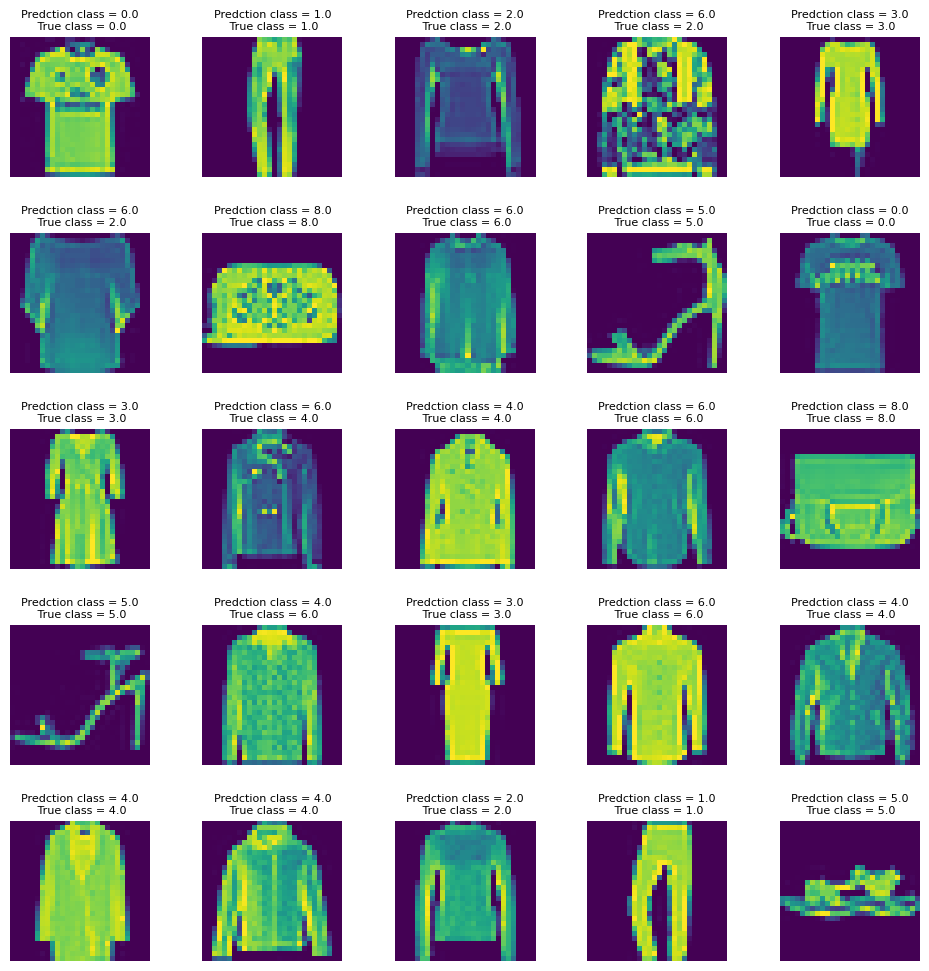

In [ ]:
# Com as classes preditas e classes reais podemos visualizar e comparar:

W_grid = 5
L_grid = 5
fig, axes = plt.subplots(L_grid, W_grid, figsize = (12,12))
axes = axes.ravel()

for i in np.arange(0, W_grid * L_grid):
  axes[i].imshow(x_test[i].reshape((28,28)))
  axes[i].set_title("Predction class = {:0.1f}\n True class = {:0.1f}".format(predicted_classes[i], y_test[i]), fontsize = 8)
  axes[i].axis('off')
plt.subplots_adjust(hspace=0.4)

<Axes: >

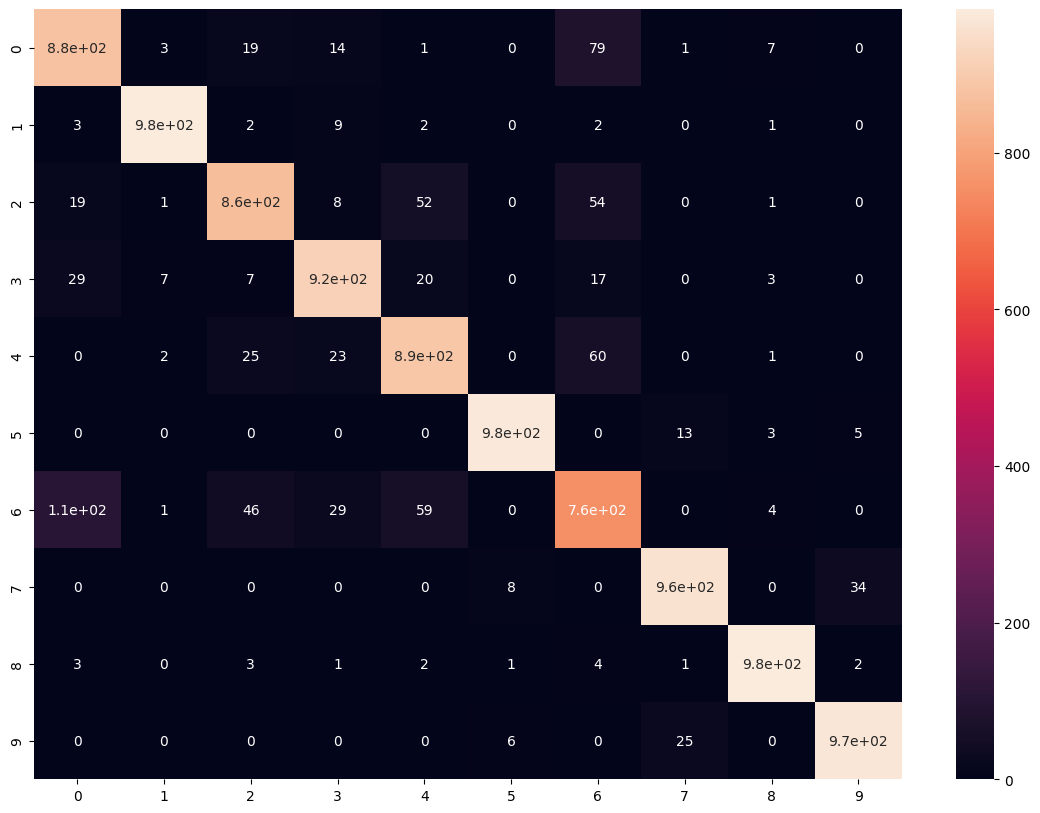

In [ ]:
# Matriz de confusão: erros e acertos

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, predicted_classes)
plt.figure(figsize = (14,10))
sns.heatmap(cm, annot=True)

In [ ]:
cm

array([[876,   3,  19,  14,   1,   0,  79,   1,   7,   0],
       [  3, 981,   2,   9,   2,   0,   2,   0,   1,   0],
       [ 19,   1, 865,   8,  52,   0,  54,   0,   1,   0],
       [ 29,   7,   7, 917,  20,   0,  17,   0,   3,   0],
       [  0,   2,  25,  23, 889,   0,  60,   0,   1,   0],
       [  0,   0,   0,   0,   0, 979,   0,  13,   3,   5],
       [106,   1,  46,  29,  59,   0, 755,   0,   4,   0],
       [  0,   0,   0,   0,   0,   8,   0, 958,   0,  34],
       [  3,   0,   3,   1,   2,   1,   4,   1, 983,   2],
       [  0,   0,   0,   0,   0,   6,   0,  25,   0, 969]])

In [ ]:
from sklearn.metrics import classification_report
num_classes = 10
target_names = ["Class {}".format(i) for i in range(num_classes)]
target_names

['Class 0',
 'Class 1',
 'Class 2',
 'Class 3',
 'Class 4',
 'Class 5',
 'Class 6',
 'Class 7',
 'Class 8',
 'Class 9']

In [ ]:
# Classification Report: relatório detalhado de desempenho por classe
print(classification_report(y_test, predicted_classes, target_names=target_names))

              precision    recall  f1-score   support

     Class 0       0.85      0.88      0.86      1000
     Class 1       0.99      0.98      0.98      1000
     Class 2       0.89      0.86      0.88      1000
     Class 3       0.92      0.92      0.92      1000
     Class 4       0.87      0.89      0.88      1000
     Class 5       0.98      0.98      0.98      1000
     Class 6       0.78      0.76      0.77      1000
     Class 7       0.96      0.96      0.96      1000
     Class 8       0.98      0.98      0.98      1000
     Class 9       0.96      0.97      0.96      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000

